
# Исследование f-принципа в MLP

Ноутбук содержит серию экспериментов для исследования влияния:

1. Шага обучения
2. Ширины сети


На каждой эпохе измеряются спектры целевой функции и предсказания сети:


$$E_k(t)=|\hat f(k)-\hat f_\theta(k,t)|^2$$

Строятся:
- кривые ошибок по модам;
- теплокарты «частота × эпоха»;
- сравнения различных гиперпараметров.


In [1]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

def set_seed(seed=42):
    random.seed(seed)                # стандартный python
    np.random.seed(seed)             # numpy
    torch.manual_seed(seed)          # CPU
    torch.cuda.manual_seed(seed)     # GPU
    torch.cuda.manual_seed_all(seed) # все GPU

set_seed(42)

torch.use_deterministic_algorithms(True)

device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)
print(torch.__version__)             # например, 2.1.0+cpu или 2.1.0+cu121
print(torch.version.cuda) 

cuda
2.12.0+cu130
13.0


In [2]:
def generate_1d_function(n_samples=1024, freqs=[3, 6, 9, 12, 15, 18, 21, 24, 27, 30], amplitudes=None):
    x = np.linspace(0, 2*np.pi, n_samples)
    
    if amplitudes is None:
        amplitudes = np.ones(len(freqs))
    
    y = np.zeros_like(x)
    for a, f in zip(amplitudes, freqs):
        y += a * np.sin(f * x)
    
    return x[:,None].astype(np.float32), y[:,None].astype(np.float32)


def fourier_coeffs(y):
    y=np.asarray(y).reshape(-1)
    return np.abs(np.fft.rfft(y))/len(y)


def modal_error(y_true,y_pred):
    ft=fourier_coeffs(y_true)
    fp=fourier_coeffs(y_pred)

    m=min(len(ft),len(fp))

    return (ft[:m]-fp[:m])**2


In [3]:

class MLP(nn.Module):

    def __init__(self,
                 in_dim=1,
                 out_dim=1,
                 width=128,
                 depth=3,
                 activation='relu',
                 seed=42):

        super().__init__()
        set_seed(seed)

        acts={
            'relu':nn.ReLU,
            'tanh':nn.Tanh,
            'gelu':nn.GELU,
            'sigmoid':nn.Sigmoid
        }

        layers=[]

        d=in_dim
        for _ in range(depth):
            layers.append(nn.Linear(d,width))
            layers.append(acts[activation]())
            d=width

        layers.append(nn.Linear(d,out_dim))

        self.net=nn.Sequential(*layers)

    def forward(self,x):
        return self.net(x)


In [4]:
def train_and_measure(
    lr=1e-2,
    activation='tanh',
    loss_name='mse',
    width=256,
    depth=6,
    out_dim=1,
    epochs=10000,
    seed=42):

    set_seed(seed)

    x,y=generate_1d_function()

    if out_dim>1:
        y=np.repeat(y,out_dim,axis=1)

    x_tensor=torch.tensor(x,device=device)
    y_tensor=torch.tensor(y,device=device)

    model=MLP(
        width=width,
        depth=depth,
        activation=activation,
        out_dim=out_dim,
        seed=seed
    ).to(device)


    if loss_name=='mse':
        criterion=nn.MSELoss()
    elif loss_name=='l1':
        criterion=nn.L1Loss()
    else:
        criterion=nn.SmoothL1Loss()

    heat=[]

    for epoch in range(epochs):

        # прямой проход 
        pred = model(x_tensor)
        loss = criterion(pred, y_tensor)
        
        # вычисление градиентов 
        loss.backward()
        
        # явный шаг градиентного спуска
        with torch.no_grad(): # отключаем автоматическое обновление параметров
            for param in model.parameters():
                param -= lr * param.grad
        
        # обнуление градиентовв, чтобы избежать накопления
        model.zero_grad()

        with torch.no_grad():
            p=pred[:,0].detach().cpu().numpy()
            heat.append(modal_error(y[:,0],p))

    print(f"Epoch {epoch}, Learning rate {lr}, Loss {loss.item():.6f}")

    return np.array(heat)


In [5]:

TARGET_FREQS = [1, 3, 8, 16, 32]

def plot_f_principle_panel(heat, title, freqs=TARGET_FREQS):

    import numpy as np
    import matplotlib.pyplot as plt

    # Берём только те частоты, которые присутствуют в целевой функции
    valid_freqs = [f for f in freqs if f < heat.shape[1]]
    heat_sel = heat[:, valid_freqs]

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(13, 5),
        gridspec_kw={"width_ratios": [1.1, 1.4]}
    )

    # Слева — ошибка по модам
    for i, f in enumerate(valid_freqs):
        ax1.plot(
            np.arange(heat_sel.shape[0]),
            heat_sel[:, i],
            label=f"k={f}"
        )

    ax1.set_yscale("log")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Modal error $E_k$")
    ax1.set_title("Error by modes")
    ax1.legend()

    # Справа — теплокарта
    im = ax2.imshow(
        heat_sel,
        aspect="auto",
        origin="lower"
    )

    ax2.set_xticks(range(len(valid_freqs)))
    ax2.set_xticklabels(valid_freqs)
    ax2.set_xlabel("Frequency")
    ax2.set_ylabel("Epoch")
    ax2.set_title("Heatmap of modal errors")

    cbar = fig.colorbar(im, ax=ax2)
    cbar.set_label("Ek")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## Эксперимент 1. Шаг обучения

Epoch 9999, Learning rate 0.0001, Loss 4.700032


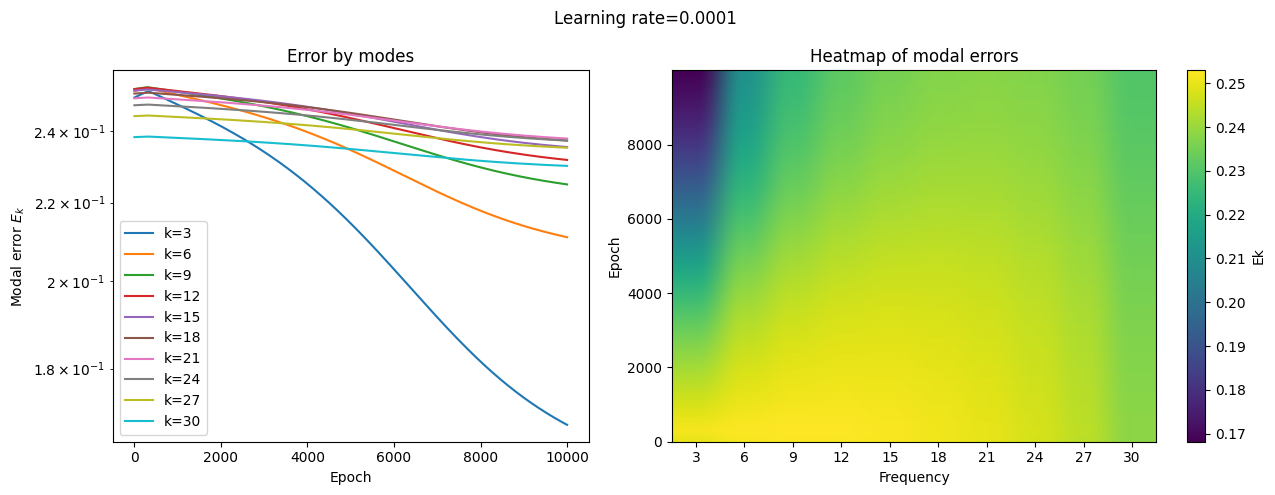

Epoch 9999, Learning rate 0.001, Loss 4.151364


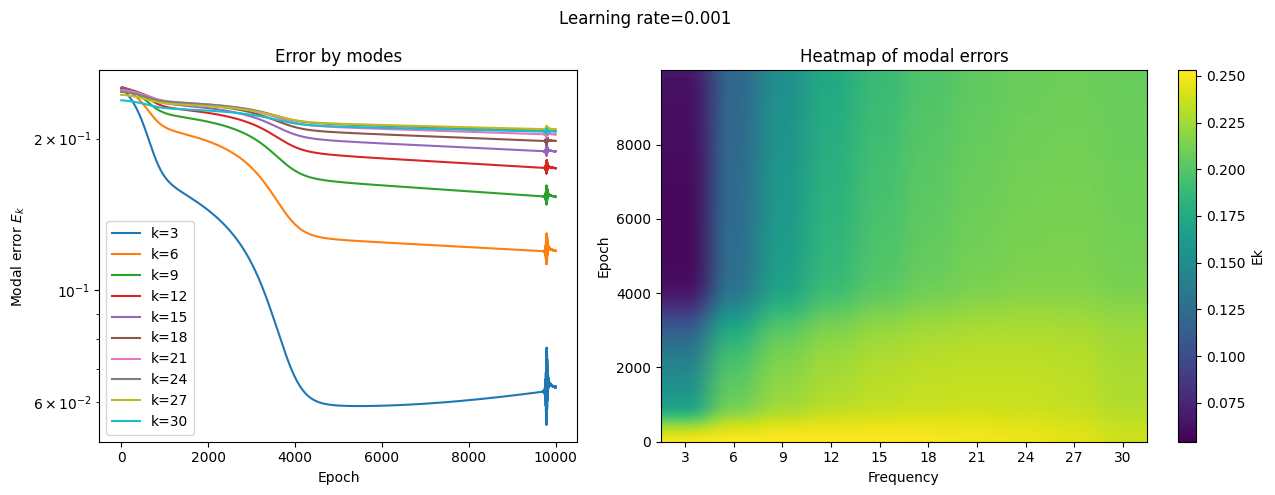

Epoch 9999, Learning rate 0.01, Loss 2.433765


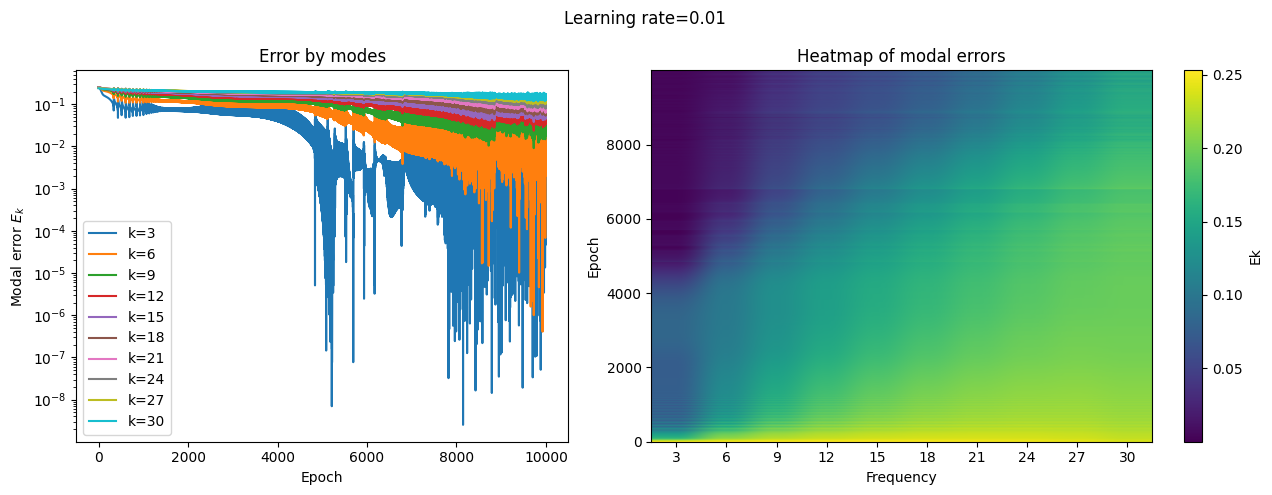

C:\Users\Богдан\AppData\Local\Temp\ipykernel_21660\867848612.py:25: RuntimeWarning: overflow encountered in square
  return (ft[:m]-fp[:m])**2


In [ ]:

# Влияние шага обучения
set_seed(42)
for lr in [1e-4, 1e-3, 1e-2, 1e-1]:
    heat=train_and_measure(lr=lr, seed=42)
    plot_f_principle_panel(heat,f'Learning rate={lr}', freqs=[3, 6, 9, 12, 15, 18, 21, 24, 27, 30])

### Проверка диапозона $\eta = 0.1,0.2,...,0.1$

Epoch 9999, Learning rate 0.01, Loss 2.433765


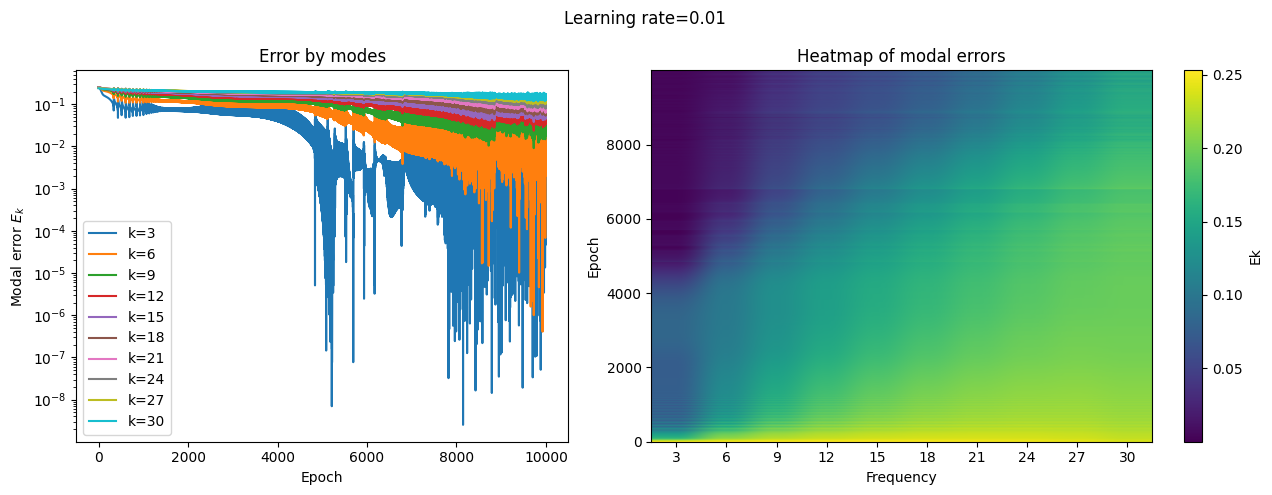

Epoch 9999, Learning rate 0.02, Loss 1.957742


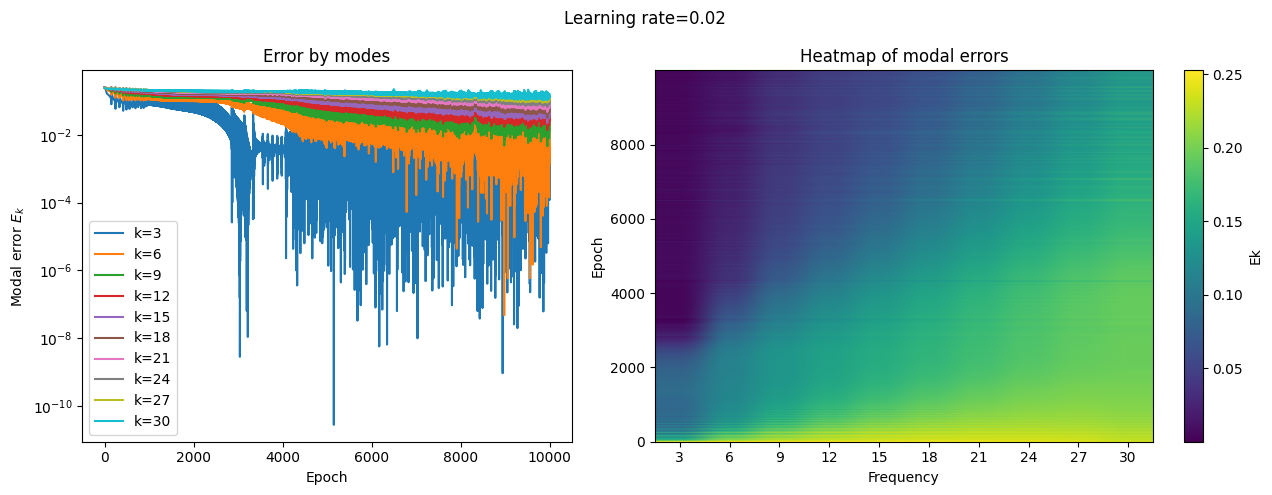

Epoch 9999, Learning rate 0.03, Loss 1.928211


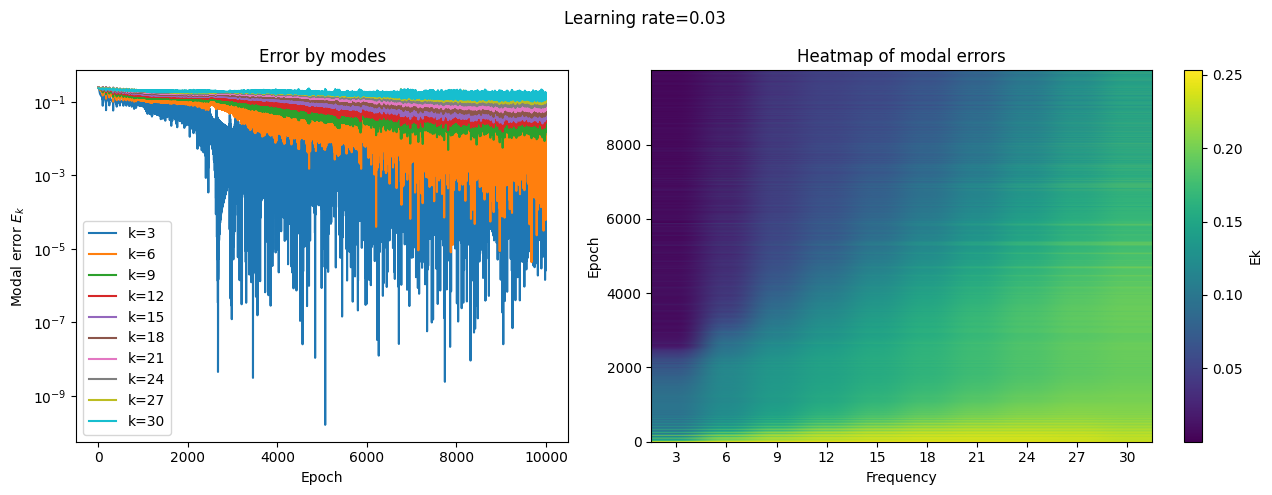

Epoch 9999, Learning rate 0.04, Loss 1.931589


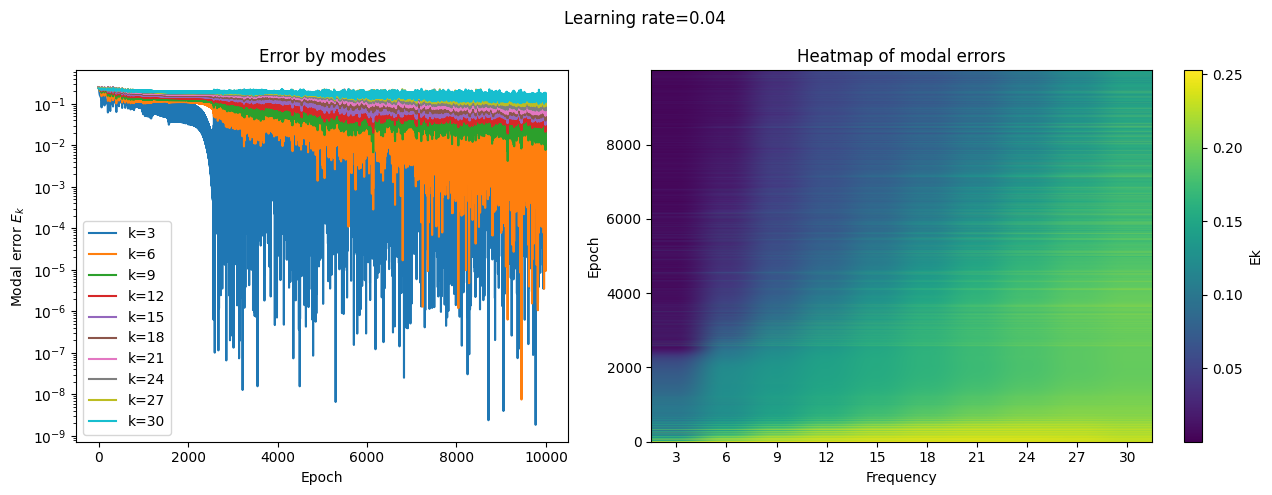

Epoch 9999, Learning rate 0.05, Loss 2.186523


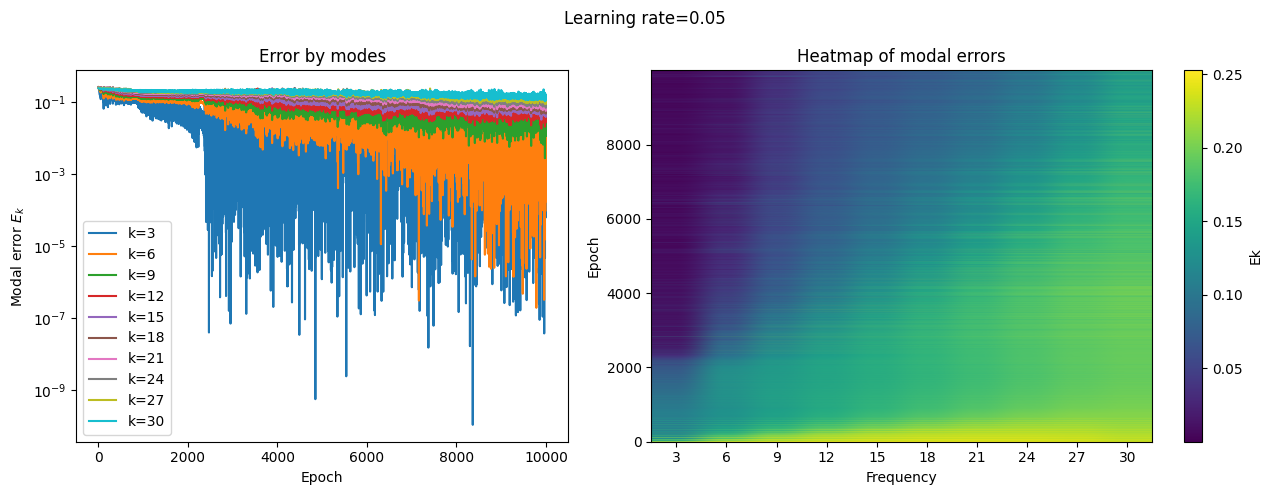

Epoch 9999, Learning rate 0.06, Loss 3.826989


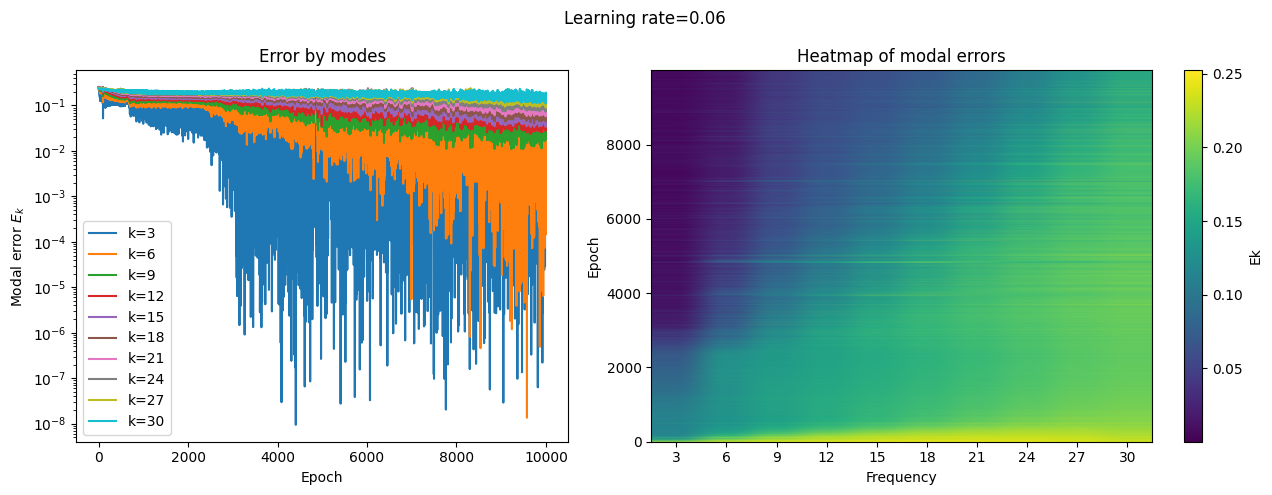

Epoch 9999, Learning rate 0.07, Loss 2.819259


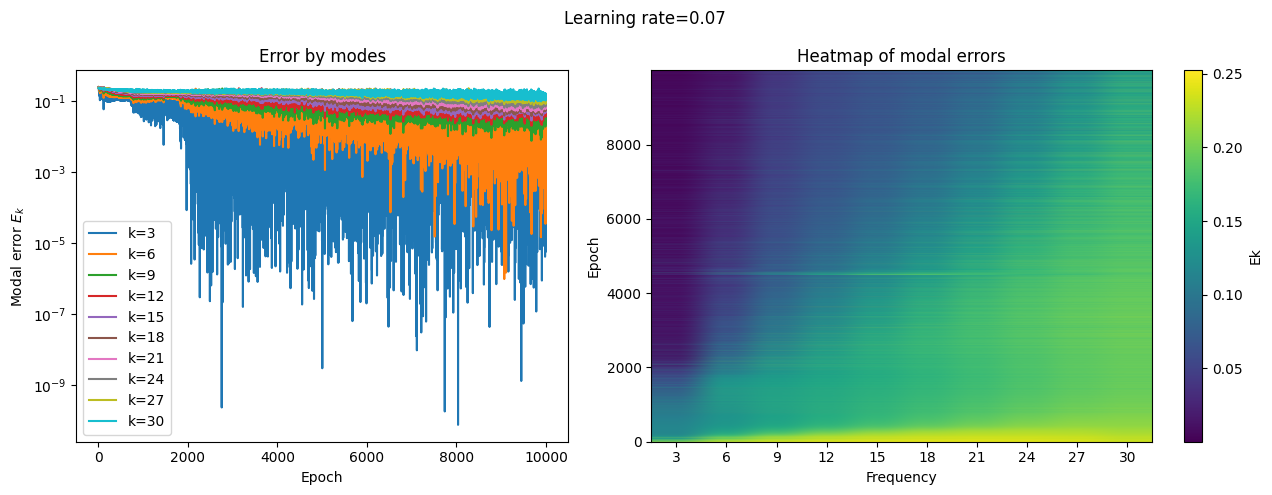

Epoch 9999, Learning rate 0.08, Loss 2.635447


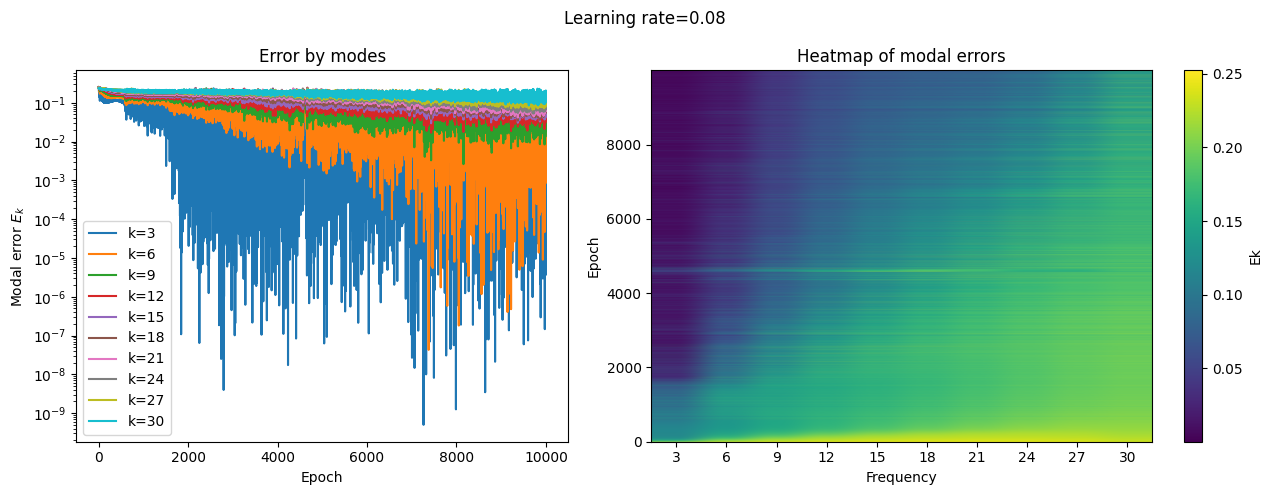

Epoch 9999, Learning rate 0.09, Loss 3.086915


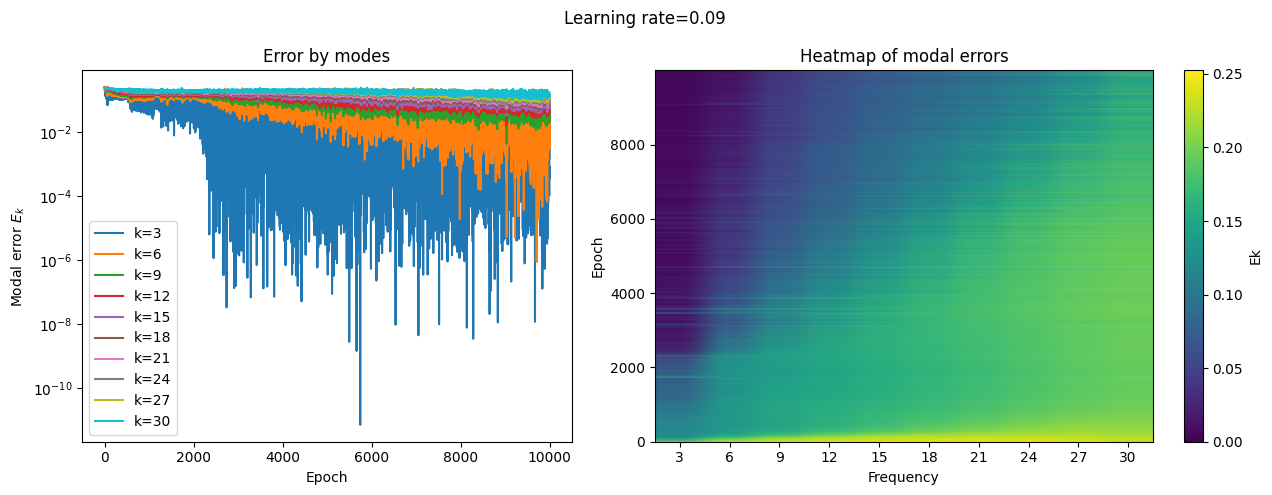

C:\Users\Богдан\AppData\Local\Temp\ipykernel_19076\867848612.py:25: RuntimeWarning: overflow encountered in square
  return (ft[:m]-fp[:m])**2


Epoch 9999, Learning rate 0.1, Loss nan


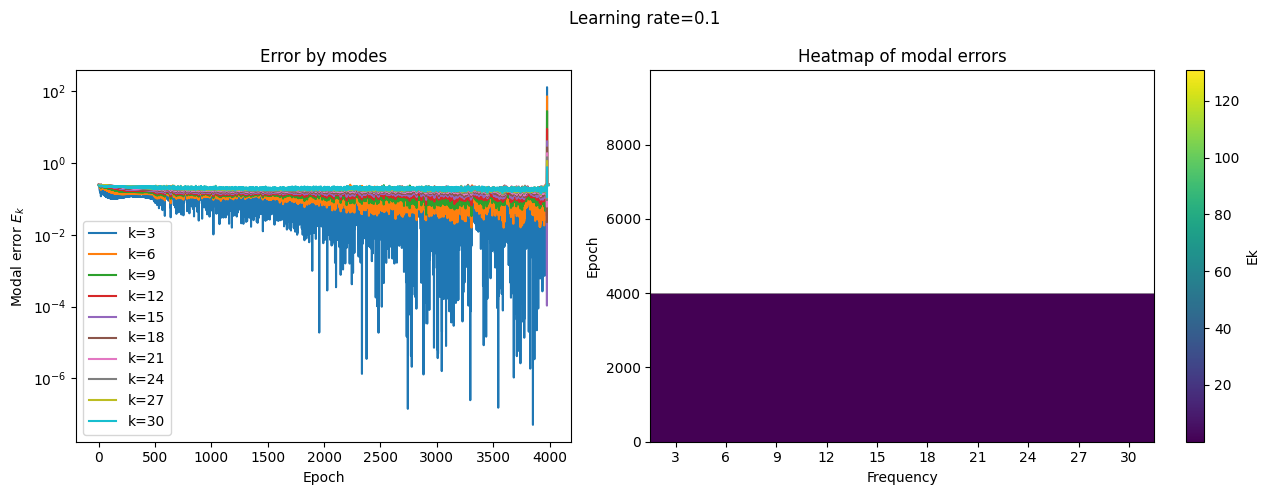

In [ ]:
# Влияние шага обучения
set_seed(42)
for lr in [1e-2, 2e-2, 3e-2, 4e-2, 5e-2, 6e-2, 7e-2, 8e-2, 9e-2, 1e-1]:
    heat=train_and_measure(lr=lr)
    plot_f_principle_panel(heat,f'Learning rate={lr}', freqs=[3, 6, 9, 12, 15, 18, 21, 24, 27, 30])

## Эксперимент 2. Ширина сети

Epoch 9999, Learning rate 0.001, Loss 4.375099


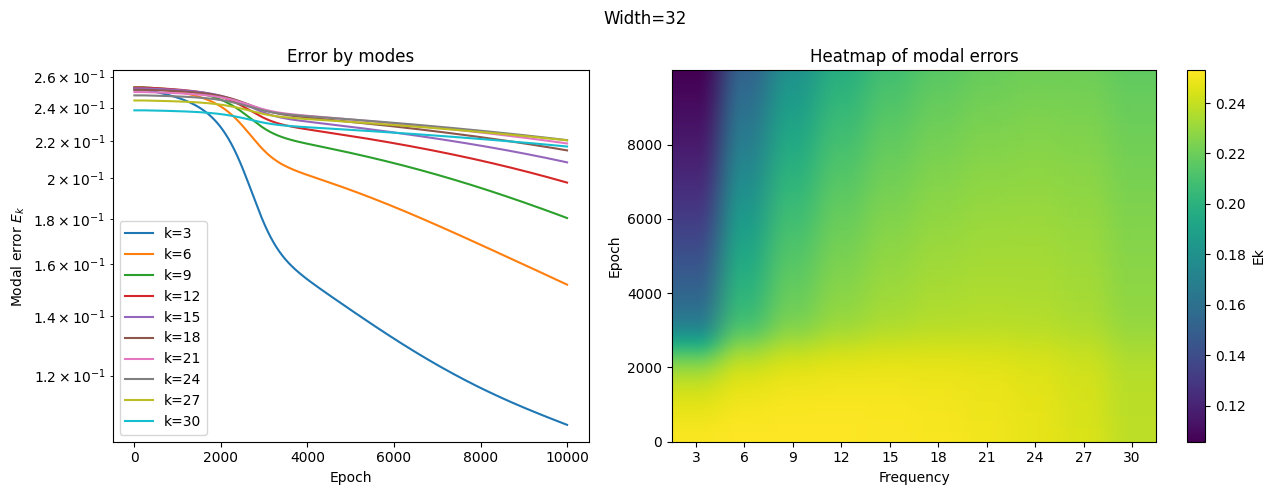

Epoch 9999, Learning rate 0.001, Loss 4.177872


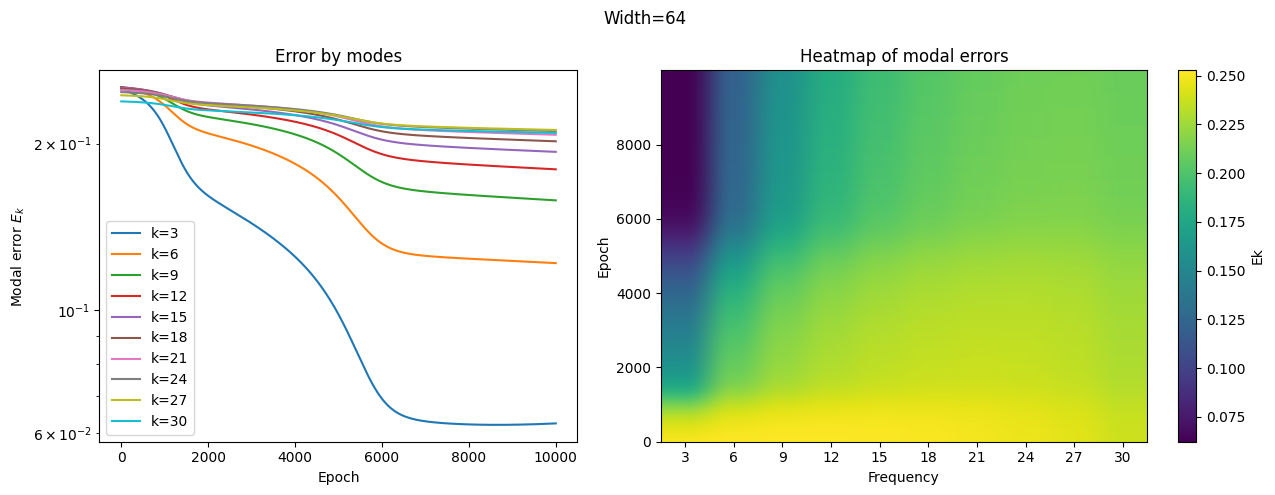

Epoch 9999, Learning rate 0.001, Loss 4.173312


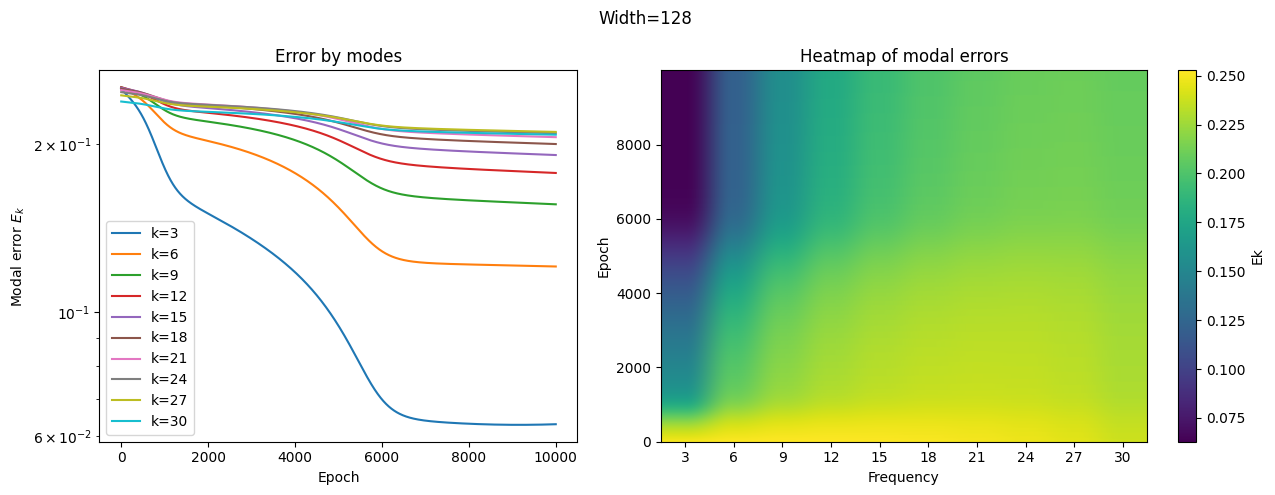

Epoch 9999, Learning rate 0.001, Loss 4.151364


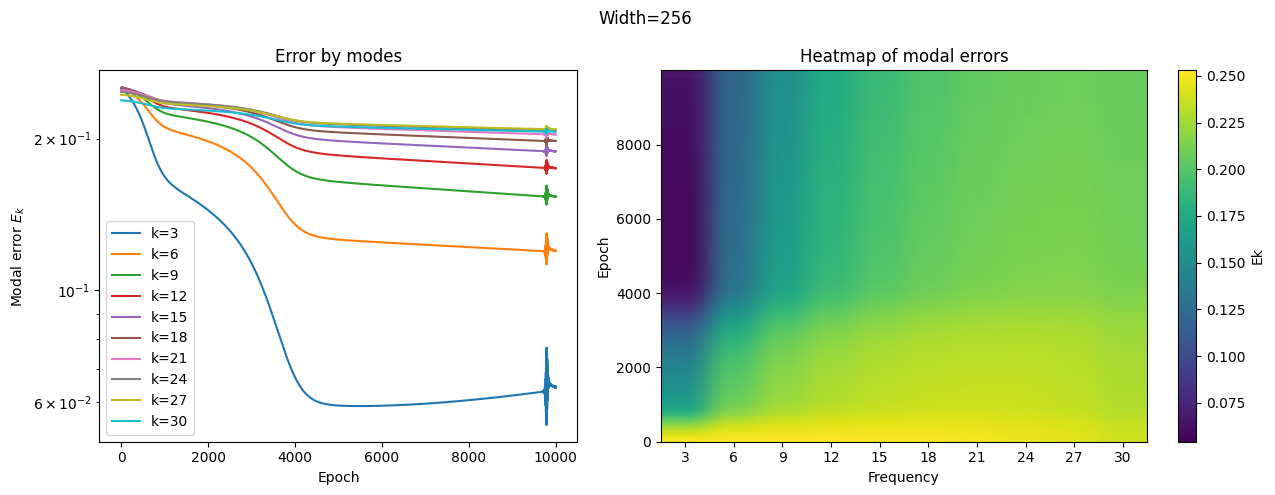

Epoch 9999, Learning rate 0.001, Loss 4.172631


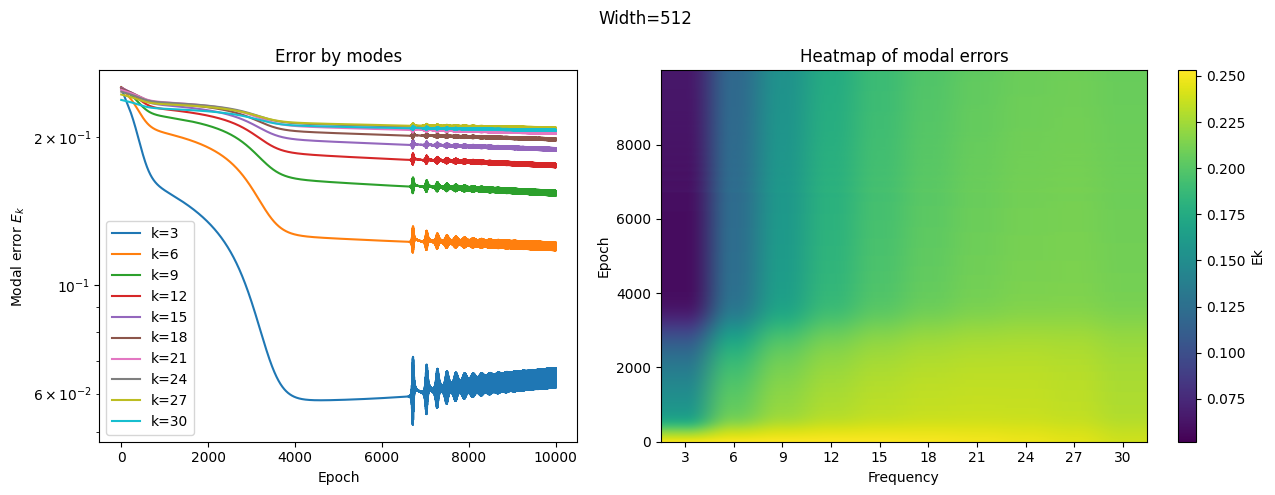

Epoch 9999, Learning rate 0.001, Loss 4.177126


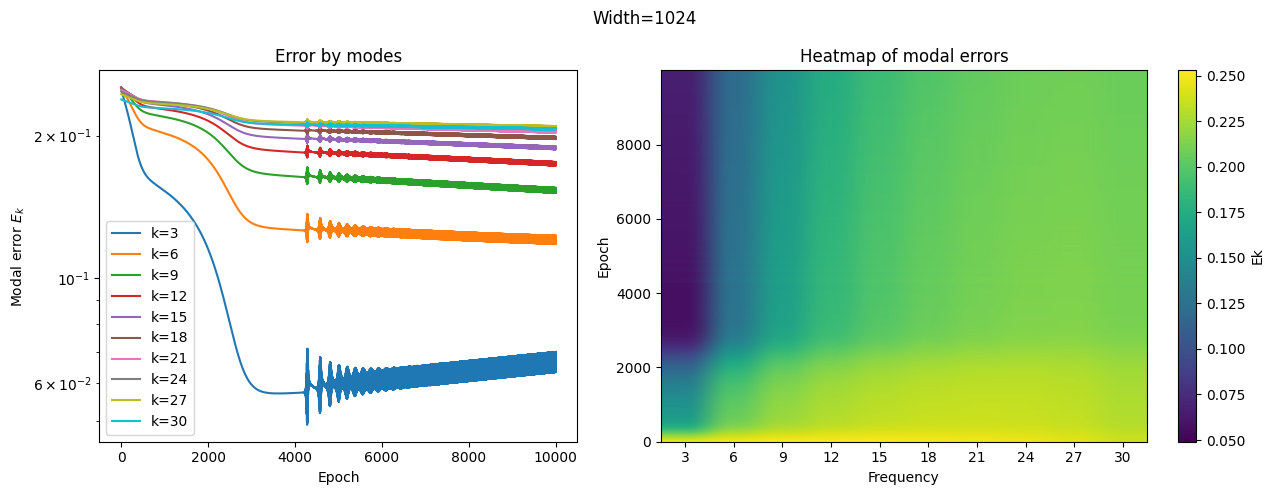

Epoch 9999, Learning rate 0.001, Loss 4.170064


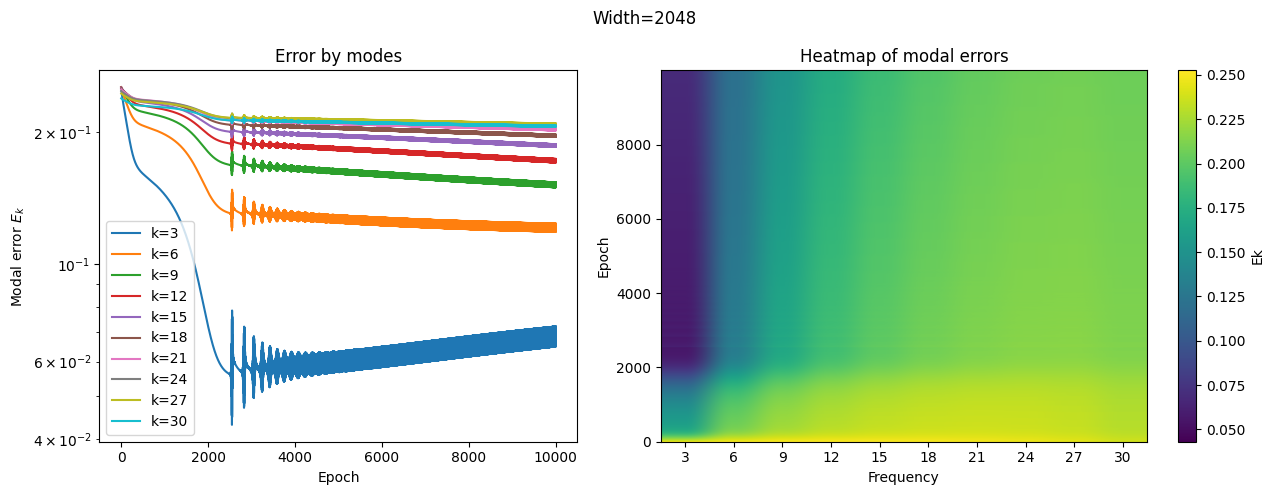

Epoch 9999, Learning rate 0.001, Loss 4.168248


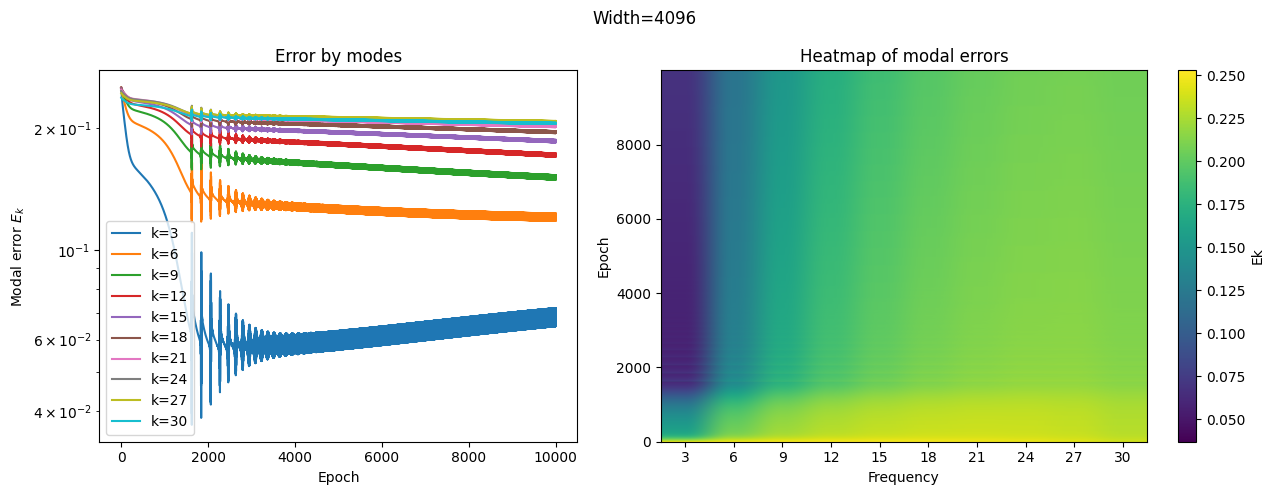

In [ ]:

for w in [32, 64, 128, 256, 512, 1024, 2048, 4096]:
    heat=train_and_measure(width=w, seed=42)
    plot_f_principle_panel(heat,f'Width={w}', freqs=[3, 6, 9, 12, 15, 18, 21, 24, 27, 30])